GNN

In [1]:
# node2vec 설치
!pip install node2vec

In [2]:
!pip install torch_geometric

# Node2Vec

In [3]:
import pandas as pd

In [4]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
movies_path = "Netflix_Dataset_Movie.csv"
ratings_path = "Netflix_Dataset_Rating.csv"

# Load the latest version
movies = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rishitjavia/netflix-movie-rating-dataset",
  movies_path,
)
ratings = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rishitjavia/netflix-movie-rating-dataset",
  ratings_path,
)

print("First 5 records:", movies.head())
print("First 5 records:", ratings.head())

/tmp/ipykernel_3639/810459321.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  movies = kagglehub.load_dataset(


100%|██████████| 558k/558k [00:00<00:00, 23.3MB/s]
/tmp/ipykernel_3639/810459321.py:14: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  ratings = kagglehub.load_dataset(


100%|██████████| 74.5M/74.5M [00:01<00:00, 48.8MB/s]

Extracting zip of Netflix_Dataset_Rating.csv...


First 5 records:    Movie_ID  Year                          Name
0         1  2003               Dinosaur Planet
1         2  2004    Isle of Man TT 2004 Review
2         3  1997                     Character
3         4  1994  Paula Abdul's Get Up & Dance
4         5  2004      The Rise and Fall of ECW
First 5 records:    User_ID  Rating  Movie_ID
0   712664       5         3
1  1331154       4         3
2  2632461       3         3
3    44937       5         3
4   656399       4         3


In [5]:
movies

,Movie_ID,Year,Name
0,1,2003,Dinosaur Planet
1,2,2004,Isle of Man TT 2004 Review
2,3,1997,Character
3,4,1994,Paula Abdul's Get Up & Dance
4,5,2004,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004,Fidel Castro: American Experience
17767,17768,2000,Epoch
17768,17769,2003,The Company


In [6]:
ratings

,User_ID,Rating,Movie_ID
0,712664,5,3
1,1331154,4,3
2,2632461,3,3
3,44937,5,3
4,656399,4,3
...,...,...,...
17337453,520675,3,4496
17337454,1055714,5,4496
17337455,2643029,4,4496
17337456,1559566,3,4496


In [7]:
# Ratings의 Movie_ID 열 값을 int 형으로 변환하고, 결측치 제거
ratings = ratings.dropna(subset=['Movie_ID'])
ratings['Movie_ID'] = ratings['Movie_ID'].astype(int)

In [8]:
# ratings 데이터에서 User_ID와 Movie_ID 열만 추출하고, 중복으로 준 평점 제거
ratings_1 = ratings[['User_ID', 'Movie_ID']].drop_duplicates()

In [9]:
# 유저별 영화 리스트 만들기
user_movies = ratings_1.groupby('User_ID')['Movie_ID'].apply(list)
user_movies

,Movie_ID
User_ID,
6,"[30, 173, 175, 191, 197, 241, 295, 299, 329, 3..."
7,"[8, 28, 30, 83, 175, 185, 191, 257, 273, 283, ..."
79,"[30, 84, 148, 191, 225, 257, 262, 285, 299, 31..."
97,"[83, 167, 175, 270, 275, 299, 313, 329, 353, 3..."
134,"[28, 55, 58, 77, 118, 143, 148, 191, 270, 273,..."
...,...
2649370,"[197, 290, 313, 357, 406, 457, 483, 571, 705, ..."
2649378,"[28, 30, 191, 197, 285, 299, 313, 457, 468, 55..."
2649388,"[30, 97, 241, 270, 312, 313, 357, 482, 571, 86..."


In [10]:
# 사용자별로 본 영화 2개씩 Combination으로 묶기
from tqdm import tqdm
from collections import Counter
from itertools import combinations

edge_counter = Counter()

for movie_list in tqdm(user_movies, desc="Calculating Edges"):
    if len(movie_list) < 2 or len(movie_list) > 40:
        continue

    for m1, m2 in combinations(sorted(set(movie_list)), 2):
        edge_counter[(m1, m2)] += 1

Calculating Edges: 100%|██████████| 143458/143458 [00:00<00:00, 302626.01it/s]


In [11]:
# edge를 데이터프레임으로 보기
edges_df = pd.DataFrame([(m1, m2, w) for (m1, m2), w in edge_counter.items()],
                        columns = ['MovieId1', 'MovieId2', 'Weight'])
edges_df

,MovieId1,MovieId2,Weight
0,118,189,1
1,118,281,2
2,118,483,2
3,118,1307,1
4,118,1435,2
...,...,...,...
199405,3775,4490,1
199406,3879,4127,1
199407,3955,4127,1
199408,3955,4490,1


In [12]:
# 너무 약한 연결 제거
edges_df = edges_df[edges_df['Weight'] >= 3].copy()

In [13]:
# NetworkX로 그래프 만들기
import networkx as nx
G = nx.Graph()

for _, row in edges_df.iterrows():
    G.add_edge(row['MovieId1'], row['MovieId2'], weight=row['Weight'])

In [14]:
# 노드 개수
G.number_of_nodes()

1079

In [15]:
# 엣지 개수
G.number_of_edges()

36976

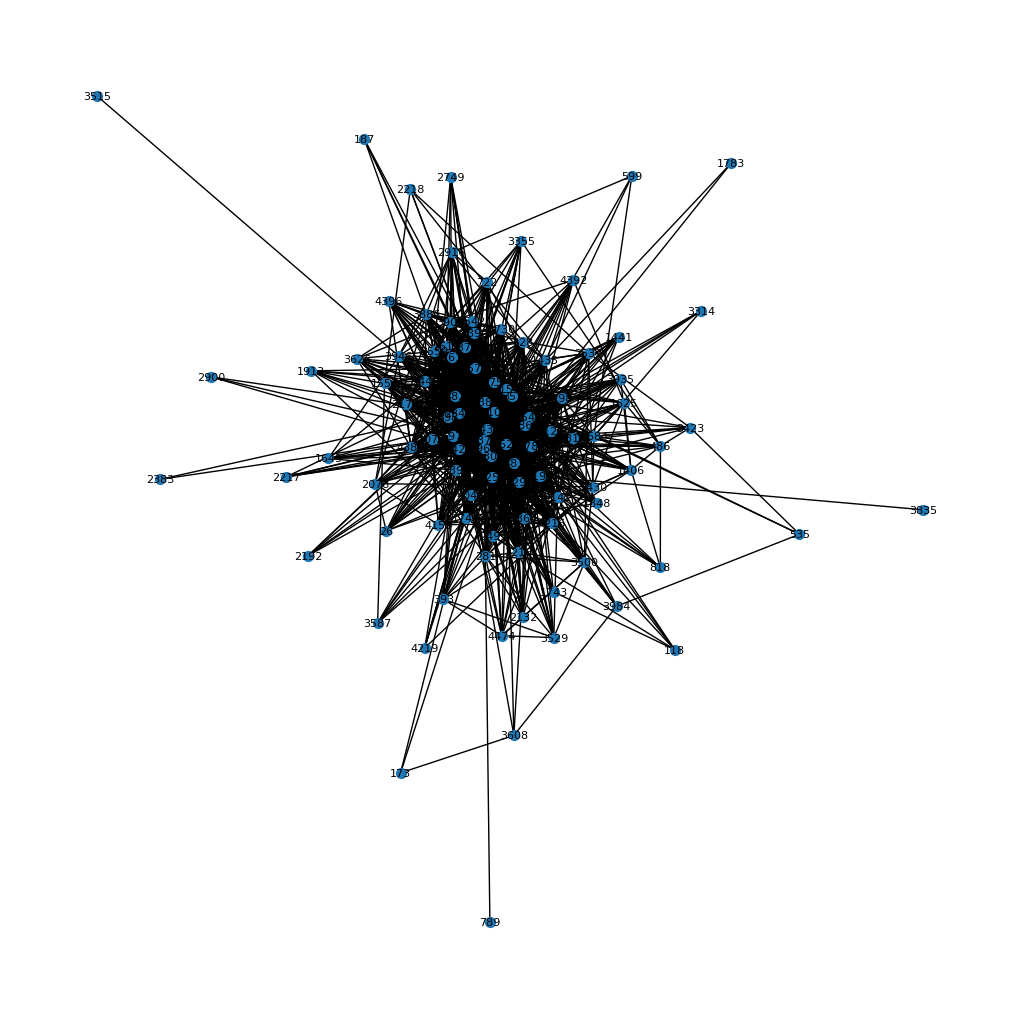

In [16]:
# 작은 샘플만 시각화 하기
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
subgraph = G.subgraph(list(G.nodes)[:100])  # 처음 100개 노드로 서브그래프 생성
nx.draw(subgraph, with_labels=True, node_size=50, font_size=8)
plt.show()

In [17]:
from node2vec import Node2Vec

node2vec = Node2Vec(
    G,
    dimensions=16, # 노드를 몇개의 차원으로 표현할지
    walk_length=4, # 랜덤워크 할때 몇단계 까지 갈지
    num_walks=3, # 각 노드마다 랜덤워크 실행 횟수
    workers=8, # CPU 동원 개수
    weight_key='weight', # 엣지 가중치 반영
    quiet=False # 진행상황
)

Computing transition probabilities:   0%|          | 0/1079 [00:00<?, ?it/s]

In [18]:
model = node2vec.fit(
    window=5, # 맥락의 범위
    min_count=1, # 최소 빈도 제한
    batch_words=256 # 한번에 처리하는 양
)

In [19]:
# 첫번째 임베딩 결과 보기
print(model.wv[0])

[-0.18253115 -0.23740152  0.2981413   0.45311743  0.3712747   0.2889185
  1.0371532   0.06762645 -0.12756237  0.12589943 -0.03241057 -0.48674327
  0.01998805 -0.55683815 -0.06555326  0.28199536]


In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

movie_ids = model.wv.index_to_key
print(movie_ids)

embeddings = np.array([model.wv[movie_id] for movie_id in movie_ids])
print(embeddings)



['1905', '2372', '2452', '3624', '4432', '3938', '1220', '3282', '3962', '571', '2342', '1470', '3371', '2913', '886', '1110', '457', '30', '3925', '4345', '1865', '1145', '3446', '3151', '4266', '3825', '3860', '2862', '4306', '1428', '473', '1307', '4356', '241', '3106', '191', '758', '482', '4472', '197', '2782', '2578', '3427', '2112', '2152', '3917', '1542', '872', '1962', '488', '357', '1741', '175', '361', '3756', '3875', '468', '3879', '2016', '443', '2122', '3638', '1375', '3333', '985', '2813', '3864', '483', '406', '3256', '2551', '2200', '717', '2874', '3315', '986', '607', '2558', '2015', '2391', '1595', '4390', '3197', '761', '3242', '1264', '3385', '963', '3713', '1719', '3559', '299', '2965', '677', '2992', '4315', '516', '3742', '2905', '3841', '375', '1561', '2699', '2743', '3900', '313', '1766', '334', '2617', '3290', '3138', '1435', '4123', '774', '2362', '996', '989', '3605', '1798', '3798', '28', '2360', '501', '398', '3542', '2319', '2580', '2612', '8', '954', '2

In [21]:
def recommend_top5(target_movie_id, model, top_n=5):
    movie_ids = model.wv.index_to_key
    embeddings = np.array([model.wv[movie_id] for movie_id in movie_ids])
    target_movie_id = str(target_movie_id)

    if target_movie_id not in movie_ids:
        raise ValueError(f"{target_movie_id}가 model.wv 안에 없습니다.")

    target_vector = model.wv[target_movie_id].reshape(1, -1)
    sims = cosine_similarity(target_vector, embeddings)[0]
    target_idx = movie_ids.index(target_movie_id)
    sims[target_idx] = -1
    top_idx = np.argsort(sims)[::-1][:top_n]

    result = pd.DataFrame({
        "movie_id": [movie_ids[i] for i in top_idx],
        "similarity": [sims[i] for i in top_idx]
    })

    return result

In [22]:
result = recommend_top5(1905, model, top_n=5)
print(result)

  movie_id  similarity
0     4432    0.995487
1     1865    0.995204
2     2200    0.994657
3     3256    0.993990
4     4345    0.993301


In [23]:
movies.loc[movies['Movie_ID'] == 1905]

,Movie_ID,Year,Name
1904,1905,2003,Pirates of the Caribbean: The Curse of the Bla...


In [24]:
movies.loc[movies['Movie_ID'].isin([3938, 3254, 1865, 2391, 1307])]

,Movie_ID,Year,Name
1306,1307,2003,S.W.A.T.
1864,1865,2004,Eternal Sunshine of the Spotless Mind
2390,2391,2004,Along Came Polly
3253,3254,2003,Daredevil
3937,3938,2004,Shrek 2


In [25]:
movies.head(50)

,Movie_ID,Year,Name
0,1,2003,Dinosaur Planet
1,2,2004,Isle of Man TT 2004 Review
2,3,1997,Character
3,4,1994,Paula Abdul's Get Up & Dance
4,5,2004,The Rise and Fall of ECW
5,6,1997,Sick
6,7,1992,8 Man
7,8,2004,What the #$*! Do We Know!?
8,9,1991,Class of Nuke 'Em High 2
9,10,2001,Fighter


# Vanilla GNN

In [26]:
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.utils import add_self_loops, degree

# --- hyperparameters (full ratings는 메모리 부담 → 샘플링) ---
DIM_IN = 16
DIM_HIDDEN = 64
DIM_EMB = 32
MAX_RATINGS = 200_000
EPOCHS = 50
LR = 0.01
SEED = 42

torch.manual_seed(SEED)

# --- user–movie 이분 그래프 → 동종 그래프 (user: 0..U-1, movie: U..U+M-1) ---
r = ratings.sample(n=min(MAX_RATINGS, len(ratings)), random_state=SEED).reset_index(drop=True)
r = r[r["Movie_ID"].isin(movies["Movie_ID"])]

In [27]:
movies

,Movie_ID,Year,Name
0,1,2003,Dinosaur Planet
1,2,2004,Isle of Man TT 2004 Review
2,3,1997,Character
3,4,1994,Paula Abdul's Get Up & Dance
4,5,2004,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004,Fidel Castro: American Experience
17767,17768,2000,Epoch
17768,17769,2003,The Company


In [28]:
ratings

,User_ID,Rating,Movie_ID
0,712664,5,3
1,1331154,4,3
2,2632461,3,3
3,44937,5,3
4,656399,4,3
...,...,...,...
17337453,520675,3,4496
17337454,1055714,5,4496
17337455,2643029,4,4496
17337456,1559566,3,4496


In [29]:
r

,User_ID,Rating,Movie_ID
0,1765315,4,3463
1,261735,4,2862
2,901467,2,438
3,1675556,3,1962
4,1855544,4,2523
...,...,...,...
199995,583797,4,2162
199996,1700549,4,1810
199997,1305628,3,2960
199998,1032003,4,571


In [42]:
for user_id, movie_id in zip(r["User_ID"], r["Movie_ID"]):
  print(user_id)
  print(movie_id)
  break

1765315
3463


In [47]:
user2idx = {u: i for i, u in enumerate(r["User_ID"].unique())}
movie2idx = {m: i for i, m in enumerate(r["Movie_ID"].unique())}
num_users = len(user2idx)
num_movies = len(movie2idx)
num_nodes = num_users + num_movies

src, dst = [], []
for user_id, movie_id in zip(r["User_ID"], r["Movie_ID"]):
    u = user2idx[user_id]
    m = num_users + movie2idx[movie_id]
    src.extend([u, m])
    dst.extend([m, u])

edge_index = torch.tensor([src, dst], dtype=torch.long)

# vanilla adjacency: self-loop 포함, 정규화 없음
row, col = add_self_loops(edge_index, num_nodes=num_nodes)[0]

adjacency = torch.sparse_coo_tensor(
    torch.stack([row, col]),
    torch.ones(row.size(0), dtype=torch.float),
    size=(num_nodes, num_nodes),
).coalesce()

# 초기 노드 feature: user=0, movie=Year 정규화값
movie_year_map = movies.set_index("Movie_ID")["Year"].to_dict()
x = torch.zeros(num_nodes, DIM_IN)
for movie_id, j in movie2idx.items():
    year = movie_year_map.get(movie_id, 2000)
    x[num_users + j, 0] = (year - 1900) / 100.0

edge_users = torch.tensor([user2idx[u] for u in r["User_ID"]], dtype=torch.long)
edge_movies = torch.tensor([movie2idx[m] for m in r["Movie_ID"]], dtype=torch.long)
edge_ratings = torch.tensor(r["Rating"].values, dtype=torch.float)

In [46]:
adjacency

tensor(indices=tensor([[    0,     0,     0,  ..., 99237, 99237, 99237],
                       [    0, 97888, 98046,  ..., 88157, 90150, 99237]]),
       values=tensor([0.2500, 0.0239, 0.0158,  ..., 0.2887, 0.2887, 0.1667]),
       size=(99238, 99238), nnz=499238, layout=torch.sparse_coo)

In [48]:
class VanillaGNNLayer(torch.nn.Module):
    def __init__(self, dim_in, dim_out):
        super().__init__()
        self.linear = Linear(dim_in, dim_out, bias=False)

    def forward(self, x, adjacency):
        x = self.linear(x)
        x = torch.sparse.mm(adjacency, x)
        return x


class VanillaGNN(torch.nn.Module):
    """Vanilla GNN: 2-hop(2 layer) message passing으로 노드 임베딩 생성"""

    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gnn1 = VanillaGNNLayer(dim_in, dim_h)
        self.gnn2 = VanillaGNNLayer(dim_h, dim_out)

    def forward(self, x, adjacency):
        h = self.gnn1(x, adjacency)
        h = F.relu(h)
        h = self.gnn2(h, adjacency)
        return h


def rating_loss(z, edge_users, edge_movies, edge_ratings, num_users):
    user_z = z[:num_users]
    movie_z = z[num_users:]
    pred = (user_z[edge_users] * movie_z[edge_movies]).sum(dim=1)
    return F.mse_loss(pred, edge_ratings)


gnn = VanillaGNN(DIM_IN, DIM_HIDDEN, DIM_EMB)
optimizer = torch.optim.Adam(gnn.parameters(), lr=LR, weight_decay=5e-4)
print(gnn)
print(f"nodes: {num_nodes:,} (users {num_users:,}, movies {num_movies:,}), edges: {edge_index.size(1):,}")

gnn.train()
for epoch in range(EPOCHS + 1):
    optimizer.zero_grad()
    z = gnn(x, adjacency)
    loss = rating_loss(z, edge_users, edge_movies, edge_ratings, num_users)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:>3} | MSE loss: {loss.item():.4f}")

gnn.eval()
with torch.no_grad():
    embeddings = gnn(x, adjacency)

user_emb = embeddings[:num_users]
movie_emb = embeddings[num_users:]

print(f"\nuser_emb: {user_emb.shape}, movie_emb: {movie_emb.shape}")
print(f"sample user embedding (first user): {user_emb[0, :5].tolist()}")
print(f"sample movie embedding (first movie): {movie_emb[0, :5].tolist()}")

VanillaGNN(
  (gnn1): VanillaGNNLayer(
    (linear): Linear(in_features=16, out_features=64, bias=False)
  )
  (gnn2): VanillaGNNLayer(
    (linear): Linear(in_features=64, out_features=32, bias=False)
  )
)
nodes: 99,238 (users 97,888, movies 1,350), edges: 400,000
Epoch   0 | MSE loss: 389382.3438
Epoch  10 | MSE loss: 9629.2080
Epoch  20 | MSE loss: 609.4180
Epoch  30 | MSE loss: 7.2657
Epoch  40 | MSE loss: 7.4498
Epoch  50 | MSE loss: 7.3620

user_emb: torch.Size([97888, 32]), movie_emb: torch.Size([1350, 32])
sample user embedding (first user): [0.010333174839615822, -0.010109277442097664, -0.012084723450243473, -0.00015085800259839743, 0.018504993990063667]
sample movie embedding (first movie): [2.112196207046509, -2.0664234161376953, -2.470222234725952, -0.030835915356874466, 3.782580614089966]


In [49]:
scores = torch.matmul(user_emb, movie_emb.T)
scores

tensor([[2.3438e+00, 5.4899e+00, 2.3276e-01,  ..., 2.2104e-01, 1.9757e-01,
         1.4748e-02],
        [1.6729e+00, 3.9184e+00, 1.6613e-01,  ..., 1.5776e-01, 1.4102e-01,
         1.0527e-02],
        [2.5791e+00, 6.0409e+00, 2.5612e-01,  ..., 2.4322e-01, 2.1740e-01,
         1.6229e-02],
        ...,
        [8.8873e-01, 2.0817e+00, 8.8257e-02,  ..., 8.3813e-02, 7.4915e-02,
         5.5924e-03],
        [9.0616e-01, 2.1225e+00, 8.9988e-02,  ..., 8.5456e-02, 7.6384e-02,
         5.7020e-03],
        [8.6259e-01, 2.0204e+00, 8.5662e-02,  ..., 8.1347e-02, 7.2712e-02,
         5.4279e-03]])

In [50]:
# user_id(그래프 인덱스)가 학습 데이터 r에서 평점 준 영화 → movie_emb 인덱스
user_id = 1905
watched_movie_indices = edge_movies[edge_users == user_id].unique()

user_scores = scores[user_id].clone()
user_scores[watched_movie_indices] = -float("inf")
top_movies = torch.topk(user_scores, k=10)

print("already watched (movie idx):", watched_movie_indices.tolist())
print("top-10 recommended (movie idx):", top_movies.indices.tolist())
print("scores:", top_movies.values.tolist())

already watched (movie idx): [152, 223, 255, 340, 626, 688, 768, 1192, 1343]
top-10 recommended (movie idx): [97, 131, 318, 98, 91, 109, 32, 319, 1, 397]
scores: [19.645051956176758, 17.404888153076172, 16.97443389892578, 16.01811981201172, 15.889188766479492, 15.875797271728516, 15.87348747253418, 15.439327239990234, 15.061495780944824, 14.98401165008545]


In [51]:
movies.loc[movies['Movie_ID'].isin([97, 131, 91, 32, 318, 319, 397, 98, 150, 109])]

,Movie_ID,Year,Name
31,32,2004,ABC Primetime: Mel Gibson's The Passion of the...
90,91,2005,WWE: Royal Rumble 2005
96,97,2002,Mostly Martha
97,98,1965,The Battle of Algiers: Bonus Material
108,109,1996,No Way Back
130,131,2002,Arachnid
149,150,2001,Firetrap
317,318,1994,Beyond Suspicion
318,319,1987,Straight to Hell
396,397,1946,A Night in Casablanca


# GCN

In [35]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

# 셀 3에서 만든 Netflix 그래프 재사용: x, edge_index, edge_users, edge_movies, edge_ratings, num_users


def gcn_rating_loss(z, edge_users, edge_movies, edge_ratings, num_users):
    user_z = z[:num_users]
    movie_z = z[num_users:]
    pred = (user_z[edge_users] * movie_z[edge_movies]).sum(dim=1)
    return F.mse_loss(pred, edge_ratings)


class GCN(torch.nn.Module):
    """Graph Convolutional Network (2-layer)"""

    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gcn1 = GCNConv(dim_in, dim_h)
        self.gcn2 = GCNConv(dim_h, dim_out)

    def forward(self, x, edge_index):
        h = self.gcn1(x, edge_index)
        h = torch.relu(h)
        h = self.gcn2(h, edge_index)
        return h

    def fit(self, x, edge_index, edge_users, edge_movies, edge_ratings, num_users, epochs, lr=0.01):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr, weight_decay=5e-4)
        self.train()
        for epoch in range(epochs + 1):
            optimizer.zero_grad()
            z = self(x, edge_index)
            loss = gcn_rating_loss(z, edge_users, edge_movies, edge_ratings, num_users)
            loss.backward()
            optimizer.step()
            if epoch % 10 == 0:
                print(f"Epoch {epoch:>3} | MSE loss: {loss.item():.4f}")
        return loss.item()

    @torch.no_grad()
    def embed(self, x, edge_index, num_users):
        self.eval()
        z = self(x, edge_index)
        return z[:num_users], z[num_users:]


torch.manual_seed(SEED)
gcn = GCN(DIM_IN, DIM_HIDDEN, DIM_EMB)
print(gcn)
print(f"nodes: {num_nodes:,} (users {num_users:,}, movies {num_movies:,}), edges: {edge_index.size(1):,}")

gcn.fit(x, edge_index, edge_users, edge_movies, edge_ratings, num_users, epochs=EPOCHS, lr=LR)

user_emb_gcn, movie_emb_gcn = gcn.embed(x, edge_index, num_users)
scores_gcn = torch.matmul(user_emb_gcn, movie_emb_gcn.T)

print(f"\nuser_emb_gcn: {user_emb_gcn.shape}, movie_emb_gcn: {movie_emb_gcn.shape}")
print(f"sample scores[user 0, top-3]: {torch.topk(scores_gcn[0], k=3).values.tolist()}")

GCN(
  (gcn1): GCNConv(16, 64)
  (gcn2): GCNConv(64, 32)
)
nodes: 99,238 (users 97,888, movies 1,350), edges: 400,000
Epoch   0 | MSE loss: 13.9529
Epoch  10 | MSE loss: 2.6217
Epoch  20 | MSE loss: 2.7504
Epoch  30 | MSE loss: 2.4249
Epoch  40 | MSE loss: 2.2006
Epoch  50 | MSE loss: 2.0567

user_emb_gcn: torch.Size([97888, 32]), movie_emb_gcn: torch.Size([1350, 32])
sample scores[user 0, top-3]: [5.153848648071289, 4.9006829261779785, 4.832959175109863]


In [36]:
scores = torch.matmul(user_emb_gcn, movie_emb_gcn.T)
scores

tensor([[3.2817, 4.6234, 1.4311,  ..., 1.3504, 1.3883, 1.2422],
        [3.4284, 4.8309, 1.4941,  ..., 1.4097, 1.4493, 1.2965],
        [3.6708, 5.1733, 1.5985,  ..., 1.5081, 1.5505, 1.3869],
        ...,
        [3.7802, 5.3284, 1.6451,  ..., 1.5519, 1.5956, 1.4269],
        [3.7188, 5.2417, 1.6186,  ..., 1.5270, 1.5700, 1.4041],
        [3.5176, 4.9573, 1.5320,  ..., 1.4454, 1.4860, 1.3292]])

In [37]:
# user_id(그래프 인덱스)가 학습 데이터 r에서 평점 준 영화 → movie_emb 인덱스
user_id = 1905
watched_movie_indices = edge_movies[edge_users == user_id].unique()

user_scores = scores[user_id].clone()
user_scores[watched_movie_indices] = -float("inf")
top_movies = torch.topk(user_scores, k=10)

print("already watched (movie idx):", watched_movie_indices.tolist())
print("top-10 recommended (movie idx):", top_movies.indices.tolist())
print("scores:", top_movies.values.tolist())

already watched (movie idx): [152, 223, 255, 340, 626, 688, 768, 1192, 1343]
top-10 recommended (movie idx): [97, 131, 318, 98, 32, 319, 109, 91, 1, 15]
scores: [5.56065034866333, 5.287368297576904, 5.2142720222473145, 5.134969711303711, 5.106235980987549, 5.079195022583008, 5.070529937744141, 5.04580545425415, 4.988026142120361, 4.973830223083496]


# GAT

In [38]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv

# 셀 3에서 만든 Netflix 그래프 재사용: x, edge_index, edge_users, edge_movies, edge_ratings, num_users

GAT_DIM_H = 32
GAT_HEADS = 8


def gat_rating_loss(z, edge_users, edge_movies, edge_ratings, num_users):
    user_z = z[:num_users]
    movie_z = z[num_users:]
    pred = (user_z[edge_users] * movie_z[edge_movies]).sum(dim=1)
    return F.mse_loss(pred, edge_ratings)


class GAT(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out, heads=8):
        super().__init__()
        self.gat1 = GATv2Conv(dim_in, dim_h, heads=heads)
        self.gat2 = GATv2Conv(dim_h * heads, dim_out, heads=1)

    def forward(self, x, edge_index):
        h = F.dropout(x, p=0.6, training=self.training)
        h = self.gat1(h, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=0.6, training=self.training)
        h = self.gat2(h, edge_index)
        return h

    def fit(self, x, edge_index, edge_users, edge_movies, edge_ratings, num_users, epochs, lr=0.01):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr, weight_decay=0.01)
        self.train()
        for epoch in range(epochs + 1):
            optimizer.zero_grad()
            z = self(x, edge_index)
            loss = gat_rating_loss(z, edge_users, edge_movies, edge_ratings, num_users)
            loss.backward()
            optimizer.step()
            if epoch % 10 == 0:
                print(f"Epoch {epoch:>3} | MSE loss: {loss.item():.4f}")
        return loss.item()

    @torch.no_grad()
    def embed(self, x, edge_index, num_users):
        self.eval()
        z = self(x, edge_index)
        return z[:num_users], z[num_users:]


torch.manual_seed(SEED)
gat = GAT(DIM_IN, GAT_DIM_H, DIM_EMB, heads=GAT_HEADS)
print(gat)
print(f"nodes: {num_nodes:,} (users {num_users:,}, movies {num_movies:,}), edges: {edge_index.size(1):,}")

gat.fit(x, edge_index, edge_users, edge_movies, edge_ratings, num_users, epochs=EPOCHS, lr=LR)

user_emb_gat, movie_emb_gat = gat.embed(x, edge_index, num_users)
scores_gat = torch.matmul(user_emb_gat, movie_emb_gat.T)

print(f"\nuser_emb_gat: {user_emb_gat.shape}, movie_emb_gat: {movie_emb_gat.shape}")
print(f"sample scores[user 0, top-3]: {torch.topk(scores_gat[0], k=3).values.tolist()}")

GAT(
  (gat1): GATv2Conv(16, 32, heads=8)
  (gat2): GATv2Conv(256, 32, heads=1)
)
nodes: 99,238 (users 97,888, movies 1,350), edges: 400,000
Epoch   0 | MSE loss: 8.9263
Epoch  10 | MSE loss: 1.3542
Epoch  20 | MSE loss: 2.3939
Epoch  30 | MSE loss: 1.5130
Epoch  40 | MSE loss: 1.2003
Epoch  50 | MSE loss: 1.2182

user_emb_gat: torch.Size([97888, 32]), movie_emb_gat: torch.Size([1350, 32])
sample scores[user 0, top-3]: [3.511676073074341, 3.511651039123535, 3.5116169452667236]


In [39]:
scores = torch.matmul(user_emb_gat, movie_emb_gat.T)
scores

tensor([[3.5104, 3.5107, 3.5104,  ..., 3.5103, 3.5102, 3.5098],
        [3.5258, 3.5254, 3.5268,  ..., 3.5273, 3.5265, 3.5196],
        [3.5166, 3.5166, 3.5170,  ..., 3.5171, 3.5167, 3.5137],
        ...,
        [3.5443, 3.5428, 3.5464,  ..., 3.5476, 3.5461, 3.5314],
        [3.5453, 3.5438, 3.5474,  ..., 3.5487, 3.5471, 3.5320],
        [3.5415, 3.5402, 3.5434,  ..., 3.5445, 3.5431, 3.5297]])

In [40]:
# user_id(그래프 인덱스)가 학습 데이터 r에서 평점 준 영화 → movie_emb 인덱스
user_id = 1905
watched_movie_indices = edge_movies[edge_users == user_id].unique()

user_scores = scores[user_id].clone()
user_scores[watched_movie_indices] = -float("inf")
top_movies = torch.topk(user_scores, k=10)

print("already watched (movie idx):", watched_movie_indices.tolist())
print("top-10 recommended (movie idx):", top_movies.indices.tolist())
print("scores:", top_movies.values.tolist())

already watched (movie idx): [152, 223, 255, 340, 626, 688, 768, 1192, 1343]
top-10 recommended (movie idx): [1278, 1168, 39, 902, 1114, 905, 993, 984, 986, 1140]
scores: [3.496619462966919, 3.4951443672180176, 3.495022773742676, 3.4947357177734375, 3.4947052001953125, 3.494642734527588, 3.4944956302642822, 3.494478225708008, 3.4942691326141357, 3.494065046310425]
